# CNO — o que o dado ensinou sobre como construí-lo

**O que é este caderno.** O registro de como cada achado apareceu. A ordem das
seções é a ordem em que as decisões de engenharia foram tomadas, e cada uma tem a
mesma forma: *o que eu vi → o que quebraria se eu ignorasse → o que mudou no
sistema por causa disso*.

**O que ele não é.** A entrega da análise é o dashboard (`make dashboard`). Este
caderno é o caminho, não o destino. Ele fica versionado **com as saídas** para
que seja lido sem precisar ser executado.

**Duas regras que ele segue**, e que valem tanto quanto os números:

1. **Lê de `data/curated` e não redefine regra de negócio.** `area_m2`,
   `geo_plausivel` e `serie_comparavel` chegam decididas do pipeline, e as
   consultas moram em `analise/dados.py`, o mesmo módulo que o dashboard usa. Se
   o caderno e o dashboard discordassem de um número, seria falha de arquitetura,
   não divergência de opinião.
2. **Roda de ponta a ponta**, de cima para baixo, sem célula fora de ordem.

In [1]:
import sys
from pathlib import Path

RAIZ = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "analise").is_dir())
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import pandas as pd

from analise import dados, estilo, malha, referencias

estilo.aplicar_matplotlib()
pd.set_option("display.width", 140)

curada = dados.abrir()
meta = referencias.metadados()

print(f"snapshot publicado pela Receita : {curada.snapshot}")
print(f"camada curada                   : {curada.curated_dir}")
print(
    f"referência do IBGE              : população {meta['safra_populacao']}, "
    f"válida até {meta['valido_ate']}"
)

snapshot publicado pela Receita : 2026-09-12
camada curada                   : /home/administrador/cno-data/curated
referência do IBGE              : população 2026, válida até 2027-09-19


---
## Parte 1 — O dado como ele chega

Um `.zip` de 315 MB num share da Receita, com cinco CSVs dentro. Nenhum
dicionário de tipos, nenhuma chave declarada, nenhum contrato — e 12,5 milhões de
linhas que precisam virar resposta.

A primeira coisa a fazer não é modelar. É **olhar os bytes**.

In [2]:
linhas = dados.amostra_bruta()
print(f"amostra versionada em analise/amostra_bruta.csv — {len(linhas)} linhas cruas\n")
print(dados.decodificar(linhas, "cp1252")[0][:300], "...\n")
for linha in dados.decodificar(linhas, "cp1252")[1:4]:
    print(linha[:170], "...")

amostra versionada em analise/amostra_bruta.csv — 8 linhas cruas

"CNO","Código do Pais","Nome do pais","Data de início","Data de inicio da responsabilidade","Data de registro","CNO vinculado","CEP","NI do responsável","Qualificação do responsavel","Nome","Código do municipio","Nome do município","Tipo de logradouro","Logradouro","Número do logradouro","Bairro","E ...

010010092278,105,"BRASIL",1992-02-20,1992-02-20,2022-05-17,,71215207,02688984000170,0057,"M H TECNOLOGIA LTDA",9701,"BRASÍLIA","OUTROS","SOF SUL QUADRA 1 CONJUNTO B","SN" ...
010010119379,105,"BRASIL",1991-08-01,1991-08-01,2026-06-30,,70755020,01556141000158,0070,"ENCOL S/A ENGENHARIA COMERCIO E INDUSTRIA FALIDO",9701,"BRASÍLIA","OUTROS","SQN  ...
010010144970,105,"BRASIL",1997-12-29,1997-12-29,2023-05-22,,73310303,36770931000116,0070,"SANTA PAULA ENGENHARIA E COMERCIO LTDA",9701,"BRASÍLIA","QUADRA","QUADRA 1 BLOCO ...


### Achado 1 — o encoding é cp1252, e errar não dá erro

O `cno.csv` tem **4.881 bytes na faixa `0x80`–`0x9F`**. Em cp1252 essa faixa é
tipografia: travessão, aspas curvas, bullet. Em ISO-8859-1 (o famoso `latin-1`)
ela é **caractere de controle indefinido**.

O detalhe que transforma isso de curiosidade em risco: `latin-1` **decodifica
qualquer byte sem levantar exceção**. Ler com o encoding errado não falha — só
produz lixo, e o lixo só aparece três camadas depois, num nome de empresa dentro
de um relatório.

In [3]:
for bruta, certa, errada in zip(
    linhas, dados.decodificar(linhas, "cp1252"), dados.decodificar(linhas, "latin-1"), strict=True
):
    if certa != errada:
        suspeitos = [f"0x{b:02x}" for b in bruta if 0x80 <= b <= 0x9F]
        print(f"bytes na faixa C1 : {suspeitos}")
        print(f"cp1252 (certo)    : ...{certa[100:150]}...")
        print(f"latin-1 (silencioso): ...{repr(errada[100:150])}...")
        print()

bytes na faixa C1 : ['0x93', '0x94']
cp1252 (certo)    : ...AL MISTA",8649,"ESTÂNCIA VELHA","RUA","EGON SCHIMI...
latin-1 (silencioso): ...'AL MISTA",8649,"ESTÂNCIA VELHA","RUA","EGON SCHIMI'...

bytes na faixa C1 : ['0x97']
cp1252 (certo)    : ...CAETANO DO SUL","RUA","RUA JOSE DE ALENCAR,239-DEM...
latin-1 (silencioso): ...'CAETANO DO SUL","RUA","RUA JOSE DE ALENCAR,239-DEM'...



> **O que quebraria:** nada, imediatamente. Esse é o problema. O pipeline rodaria
> verde e entregaria `AGEHAB \x96 OBRA` num relatório.
>
> **O que mudou no sistema:** `ENCODING_ORIGEM = "cp1252"` virou constante
> documentada em `config.py`; o tratamento transcodifica para UTF-8 antes de
> entregar ao DuckDB (que não lê cp1252); e há um teste cujo dado sintético
> contém o byte `0x96` de propósito — trocar o encoding para `latin-1` quebra a
> suíte em vez de quebrar o relatório.

### Achado 2 — a fonte publica o próprio gabarito

Dentro do zip vem um `cno_totais.csv` com quatro números: quantas obras, CNAEs,
áreas e vínculos aquela publicação tem. É pequeno o bastante para passar
despercebido e é a coisa mais valiosa do pacote.

Sem um oráculo externo, validação é o pipeline conferindo contra si mesmo — ou
seja, conferindo nada. Com ele, toda execução responde a uma pergunta objetiva:
*o que eu carreguei é o que a fonte disse que existe?*

In [4]:
dados.volumetria(curada)

,o_que,quantas
0,obras (uma linha por obra),3604156.0
1,municípios distintos,5571.0
2,UFs,27.0
3,áreas declaradas (1:N),4531627.0
4,CNAEs declarados (1:N),3942713.0
5,vínculos (1:N),420338.0


Os três números de baixo são a soma do 1:N depois do tratamento: **4.531.627**
áreas contra 4.553.076 publicadas, e **420.338** vínculos contra 431.211. A
diferença não é perda — são **21.449 e 10.873 linhas exatamente duplicadas** na
origem, removidas por deduplicação de linha inteira, e o número bate ao registro.

> **O que mudou no sistema:** os totais oficiais entram no manifesto na extração,
> e a validação reconcilia contra eles. É a diferença entre "o pipeline rodou" e
> "o pipeline carregou o que a Receita publicou".

---
## Parte 2 — O perfilamento, e cada decisão que ele forçou

Esta é a parte longa, e é de propósito: é aqui que o dado vira sistema.

### Achado 3 — 66% de nulos que não são dado faltante

`NI do responsável` está vazio em dois terços das obras. A leitura automática é
"coluna suja, imputar ou descartar". A leitura certa vem do dicionário da
Receita: o campo **fica em branco quando o responsável é pessoa física**.

O nulo não é ausência de informação. O nulo *é* a informação.

,tipo,obras,pct
0,PF,2392842,66.4
1,PJ,1211314,33.6


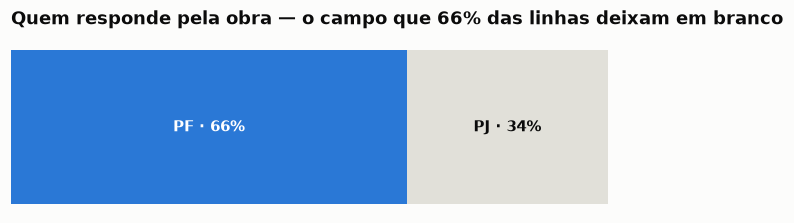

In [5]:
perfil = dados.responsavel(curada)
display(perfil)

fig, ax = plt.subplots(figsize=(7, 2.0))
esquerda = 0.0
cores = (estilo.AZUL, estilo.GRADE)
tintas = ("white", estilo.TINTA)
for (_, linha), cor, tinta in zip(perfil.iterrows(), cores, tintas, strict=False):
    ax.barh(0, linha["obras"], left=esquerda, height=0.5, color=cor)
    ax.text(
        esquerda + linha["obras"] / 2,
        0,
        f"{linha['tipo']} · {linha['pct']:.0f}%",
        ha="center",
        va="center",
        color=tinta,
        fontsize=10,
        fontweight="bold",
    )
    esquerda += linha["obras"]
ax.set_title("Quem responde pela obra — o campo que 66% das linhas deixam em branco")
ax.set_xlim(0, esquerda)
ax.axis("off")
plt.show()

> **O que quebraria:** imputar a moda transformaria 2,4 milhões de pessoas
> físicas em pessoas jurídicas. Descartar a coluna jogaria fora o recorte mais
> útil da base. Qualquer das duas seria invisível num teste.
>
> **O que mudou no sistema:** o campo virou a coluna derivada `responsavel_tipo`
> (PF/PJ) na camada tratada, e a regra de validação
> `obras.responsavel_tipo_coerente` exige que o tipo continue refletindo a
> presença do NI — se alguém um dia preencher o campo "para limpar o nulo", a
> validação reprova e a DAG cai.

### Achado 4 — a soma que mente por um fator de 312

Pergunta de primeiro slide: *quantos metros quadrados o Brasil tem em obra?*
`SUM(area_total)` responde na hora. E responde errado — por dois motivos
independentes, cada um capaz de estragar o número sozinho.

In [6]:
dados.perfil_unidades(curada)

,unidade,obras,soma_milhoes,pct_obras
0,m2,3404652,840667.6,94.46
1,Outra,156712,39990.8,4.35
2,km,21328,333.9,0.59
3,m3,14539,4866.8,0.40
4,kw,3580,1119.7,0.10
5,kva,3345,135.6,0.09


O primeiro motivo: **a coluna mistura unidades**. `Área total` guarda metro
quadrado em 94% das linhas — e quilômetro, metro cúbico, quilowatt e kVA no
restante. Somar tudo junto é somar metro com quilowatt.

O segundo: **323 obras declaram área impossível**. A maior tem
555.555.555.555 m², cerca de 65 vezes a área do Brasil. É digitação, e sozinha
ela carrega quase toda a diferença.

In [7]:
dados.areas_implausiveis(curada, 5)

,cno,uf,municipio,unidade,area_declarada,destinacao
0,900304287579,PB,GUARABIRA,m2,5.555556e+11,Comercial salas e lojas
1,900122075068,MT,CUIABÁ,m2,2.565000e+11,Residencial unifamiliar
2,900016983274,SE,GARARU,m2,6.447000e+09,Residencial unifamiliar
3,900096216673,MA,SÃO LUÍS,m2,4.046856e+09,Residencial multifamiliar
4,900176824576,RJ,ITAPERUNA,m2,3.126780e+09,Comercial salas e lojas


,ordem,criterio,km2
0,1,SUM(area_total) cru,887114.4
1,2,sem as áreas implausíveis,49285.9
2,3,só o que está em m²,840667.6
3,4,m² e sem implausíveis (area_m2),2839.0


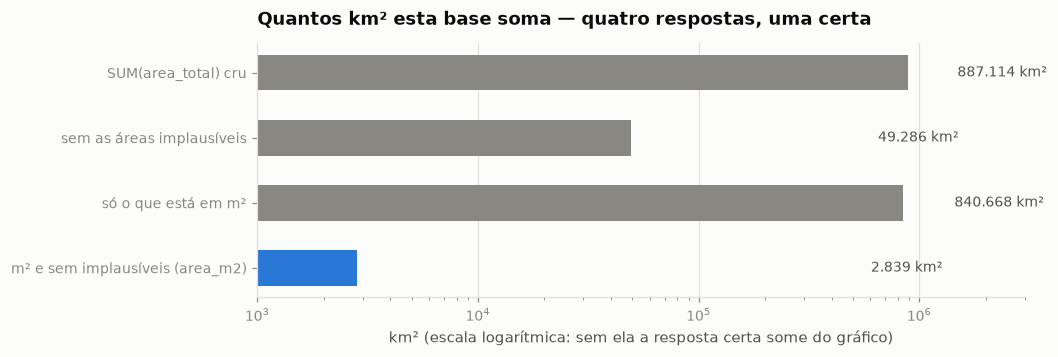

In [8]:
decomposicao = dados.decomposicao_area(curada)
display(decomposicao)

fig, ax = plt.subplots(figsize=(9, 3.0))
rotulos = list(decomposicao["criterio"])
valores = list(decomposicao["km2"])
ax.barh(rotulos, valores, height=0.55, color=estilo.enfase(rotulos, rotulos[-1]))
ax.set_xscale("log")
ax.set_xlim(1e3, 3e6)
ax.invert_yaxis()
estilo.rotular_barras(ax, valores, " km²", deslocamento=0.2)
ax.set_title("Quantos km² esta base soma — quatro respostas, uma certa", loc="left")
ax.set_xlabel("km² (escala logarítmica: sem ela a resposta certa some do gráfico)")
ax.grid(axis="y", visible=False)
plt.show()

Entre a primeira linha e a última há um **fator de 312**. Nenhum dos dois filtros
resolve sozinho: tirar só as implausíveis ainda deixa 49.286 km² (soma de
unidades diferentes); pegar só o que está em m² ainda deixa 840.668 km² (a
digitação continua lá). O número publicável, **2.839 km²**, é o que sobrevive aos
dois — e é quase duas vezes a área do município de São Paulo, que é uma ordem de
grandeza plausível para 3,4 milhões de obras cadastradas.

> **O que mudou no sistema:** a camada curada tem uma coluna `area_m2` que
> **só existe quando a unidade é metro quadrado e a área não é suspeita**. A
> declarada continua ao lado, intacta, com a unidade — marcar, nunca apagar. Só
> `area_m2` é agregável, e é a única que os marts somam.

### Achado 5 — a média de 834 m² não descreve obra nenhuma

Com a coluna agregável no lugar, dá para perguntar quanto mede uma obra. A média
e a mediana discordam por um fator de 6, e a distribuição explica por quê.

,obras_com_area,media,p25,mediana,p75,p95,p99
0,3404329,833.9,69.62,135.0,269.67,1621.14,12048.69


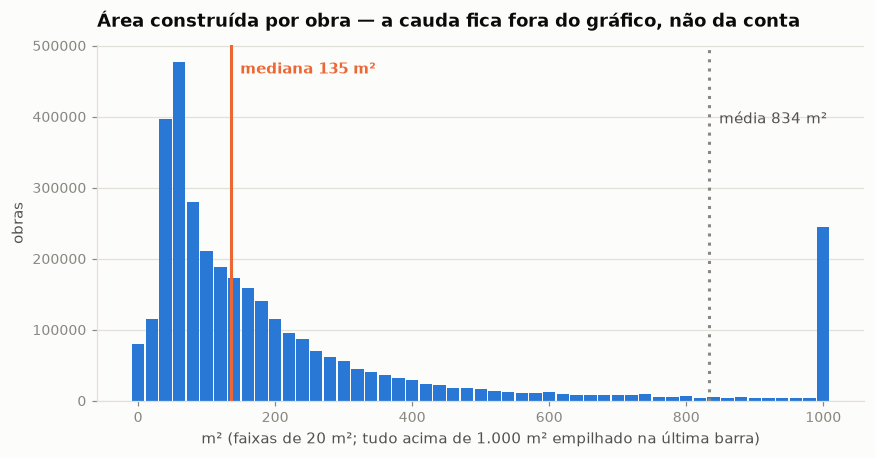

In [9]:
quantis = dados.quantis_area(curada)
display(quantis)

hist = dados.histograma_area(curada, teto=1000)
mediana = float(quantis["mediana"].iloc[0])
media = float(quantis["media"].iloc[0])

fig, ax = plt.subplots()
ax.bar(hist["faixa_inicio"], hist["obras"], width=18, color=estilo.AZUL)
ax.axvline(mediana, color=estilo.LARANJA, linewidth=2)
ax.text(
    mediana + 14,
    ax.get_ylim()[1] * 0.92,
    f"mediana {mediana:,.0f} m²".replace(",", "."),
    color=estilo.LARANJA,
    fontsize=10,
    fontweight="bold",
)
ax.axvline(media, color=estilo.CINZA, linewidth=2, linestyle=(0, (1, 2)))
ax.text(
    media + 14,
    ax.get_ylim()[1] * 0.78,
    f"média {media:,.0f} m²".replace(",", "."),
    color=estilo.TINTA_SECUNDARIA,
    fontsize=10,
)
ax.set_title("Área construída por obra — a cauda fica fora do gráfico, não da conta")
ax.set_xlabel("m² (faixas de 20 m²; tudo acima de 1.000 m² empilhado na última barra)")
ax.set_ylabel("obras")
ax.grid(axis="x", visible=False)
plt.show()

Metade das obras tem **até 135 m²**; um quarto tem até 70. A média de 834 m² é
puxada pelo 1% acima de 12.049 m² e não descreve caso nenhum.

> **O que mudou no sistema:** os marts guardam `median(area_m2)`, não só a soma;
> as faixas de `faixa_area` foram cortadas na distribuição real (70 / 150 / 500 /
> 5.000 m²) e não em números redondos; e o dashboard cita mediana onde um
> dashboard comum citaria média.

### Achado 6 — juntar quatro tabelas sem inflar a contagem

Obras, áreas, CNAEs e vínculos: duas dessas relações são 1:N legítimas. Uma obra
pode ter 75 áreas declaradas. Juntar tudo numa tabela plana multiplicaria a
contagem de obras — e **erro de cardinalidade não dá erro**: dá um número maior.

In [10]:
dados.cardinalidade(curada)

,situacao,obras
0,obras com mais de uma área,921395
1,obras sem nenhuma área,199504
2,obras com mais de um CNAE,226595
3,obras com algum vínculo,414447
4,maior número de áreas numa obra,75


> **O que mudou no sistema:** `obras_analitico` tem exatamente **uma linha por
> obra**, e o que foi colapsado fica visível em `n_areas`, `n_cnaes` e
> `n_vinculos` — a perda de informação é declarada, não escondida. Há um teste
> dedicado a essa propriedade, porque é a que falha em silêncio.

### Achado 7 — o endereço vem em Plus Code, e alguns apontam para o Japão

`Código de localização` contém um **Plus Code** (Open Location Code, do Google)
em 2,1 milhões de registros. Isso permite geocodificar sem nenhum serviço pago —
a decodificação é aritmética, roda offline.

A tentação é anunciar "59% da base geocodificada". O caminho até o número honesto
tem três degraus.

,origem,pontos,plausiveis,dist_mediana_km,dist_maxima_km
0,sem código utilizável,2071443,0,NaN,NaN
1,completo,1305859,1257423,2.43,19619.0
2,curto_recuperado,226854,226854,2.38,76.0


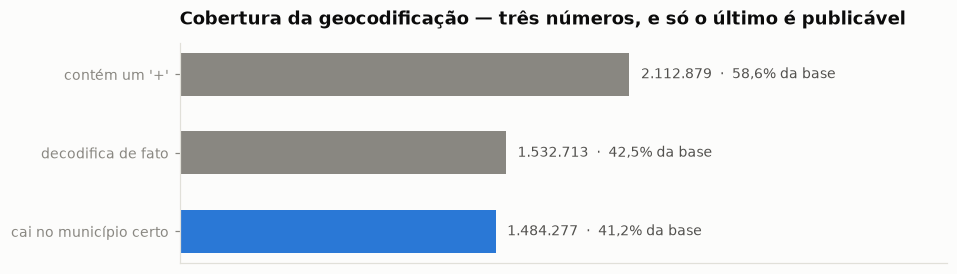

In [11]:
geo = dados.perfil_geo(curada)
display(geo)

total = int(geo["pontos"].sum())
com_mais = int(curada.valor("SELECT count(*) FROM obras WHERE contains(codigo_localizacao, '+')"))
decodificaram = int(geo.loc[geo["origem"] != "sem código utilizável", "pontos"].sum())
plausiveis = int(geo["plausiveis"].sum())

etapas = ["contém um '+'", "decodifica de fato", "cai no município certo"]
valores = [com_mais, decodificaram, plausiveis]

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.barh(etapas, valores, height=0.55, color=estilo.enfase(etapas, etapas[-1]))
ax.invert_yaxis()
ax.set_xlim(0, total)
for i, valor in enumerate(valores):
    ax.text(
        valor + total * 0.015,
        i,
        f"{estilo.numero(valor)}  ·  {estilo.percentual(valor / total)} da base",
        va="center",
        fontsize=9,
        color=estilo.TINTA_SECUNDARIA,
    )
ax.set_title("Cobertura da geocodificação — três números, e só o último é publicável")
ax.set_xticks([])
ax.grid(visible=False)
plt.show()

In [12]:
dados.distancia_geo(curada)

,faixa,pontos
0,até 150 km (plausível),1484277
1,150 a 500 km,9329
2,500 a 5.000 km,11234
3,mais de 5.000 km,27873


In [13]:
dados.pontos_fora(curada, 6)

,cno,uf,municipio,plus_code,latitude,longitude,distancia_km
0,900171168974,RS,PORTÃO,8Q4GQRQM+QR,32.789,130.835,19619.0
1,900280979779,ES,SERRA,7QGQ59G8+F6,20.176,135.366,19557.0
2,900280709573,SC,GASPAR,7QJQ62X8+P9,22.249,135.016,19358.0
3,900282976769,GO,GOIÂNIA,7QJM3933+33,22.053,133.353,19358.0
4,900300622978,PI,COCAL DOS ALVES,6Q8W9HX4+RQ,-3.600,138.557,19214.0
5,900158818264,MG,CANÁPOLIS,7QJVMC7Q+JV,22.664,137.440,19197.0


Esses pontos **decodificam perfeitamente**. `32.789, 130.835` é Kumamoto, no
Japão — a obra está declarada em Portão, no Rio Grande do Sul. O Plus Code é
válido: o que está errado é o prefixo de área, digitado trocado. Um código
sintaticamente correto pode apontar para o outro lado do planeta, e **48.436
(3,7% dos decodificados) apontam**.

Detalhe que inverte a intuição: os **códigos curtos recuperados são mais limpos
que os completos**. Todos os 226.854 são plausíveis, com distância máxima de
76 km — que é exatamente o limite geométrico de um código de 4 caracteres. A
recuperação ancorada na mediana do município é mais confiável que o dado "bom".

> **O que mudou no sistema:** a cobertura publicada é **41,2%**, não 42,5% e muito
> menos 59%. Existe a coluna `geo_plausivel` (distância até a mediana do município
> ≤ 150 km) e a coluna `geo_distancia_municipio_km` ao lado, para auditoria. O
> ponto errado **continua gravado** — quem plota filtra por `geo_plausivel`, quem
> investiga tem o caso na mão.

### Achado 8 — a série temporal triplica em dois anos, e não foi boom de construção

Obras por ano de início, sem filtro nenhum:

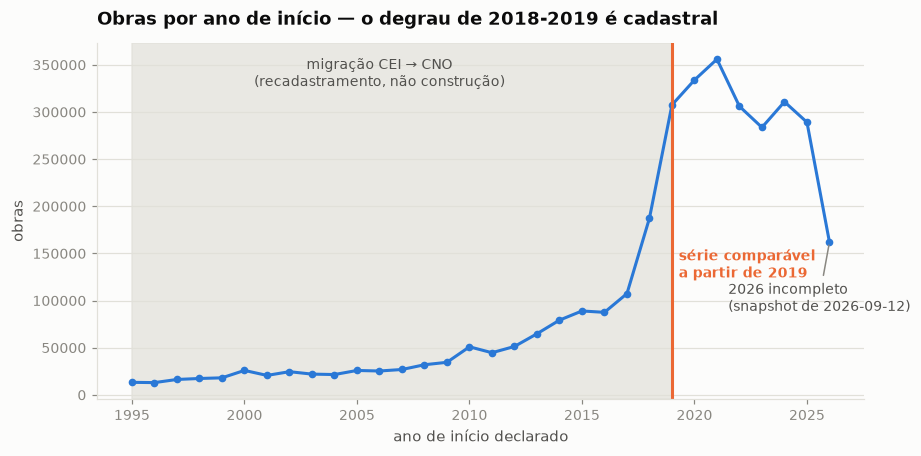

ano,2015,2016,2017,2018,2019,2020,2021,2022,2023
obras,89028.0,87574.0,107436.0,187432.0,307530.0,333924.0,356017.0,306017.0,283678.0


In [14]:
serie = dados.obras_por_ano(curada, desde=1995, ate=2026)

fig, ax = plt.subplots()
ax.plot(serie["ano"], serie["obras"], color=estilo.AZUL, marker="o", markersize=4)
ax.axvspan(1995, dados.ANO_SERIE_COMPARAVEL, color=estilo.GRADE, alpha=0.7, zorder=0)
ax.text(
    2006,
    serie["obras"].max() * 0.92,
    "migração CEI → CNO\n(recadastramento, não construção)",
    color=estilo.TINTA_SECUNDARIA,
    fontsize=9,
    ha="center",
)
ax.axvline(dados.ANO_SERIE_COMPARAVEL, color=estilo.LARANJA, linewidth=2)
ax.text(
    dados.ANO_SERIE_COMPARAVEL + 0.3,
    serie["obras"].max() * 0.35,
    f"série comparável\na partir de {dados.ANO_SERIE_COMPARAVEL}",
    color=estilo.LARANJA,
    fontsize=9,
    fontweight="bold",
)
ultimo = int(serie["ano"].max())
ax.annotate(
    f"{ultimo} incompleto\n(snapshot de {curada.snapshot})",
    xy=(ultimo, serie["obras"].iloc[-1]),
    xytext=(ultimo - 4.5, serie["obras"].iloc[-1] * 0.55),
    color=estilo.TINTA_SECUNDARIA,
    fontsize=9,
    arrowprops={"arrowstyle": "-", "color": estilo.CINZA, "linewidth": 1},
)
ax.set_title("Obras por ano de início — o degrau de 2018-2019 é cadastral")
ax.set_ylabel("obras")
ax.set_xlabel("ano de início declarado")
ax.grid(axis="x", visible=False)
plt.show()

display(serie[serie["ano"].between(2015, 2023)][["ano", "obras"]].set_index("ano").T)

87.574 obras em 2016 → 187.432 em 2018 → **307.530 em 2019** → e então estabiliza
em torno de 300 mil. Triplicar em dois anos e parar é assinatura de
**recadastramento**: o CNO substituiu a matrícula CEI, e o cadastro absorveu de
uma vez um estoque de obras antigas. O ano de início é o da obra; o ano em que
ela entrou na base, não.

> **O que quebraria:** qualquer frase com "crescimento de X% desde 2016" estaria
> medindo mudança de norma, não atividade econômica. É o tipo de erro que
> sobrevive à revisão porque o gráfico é bonito e a conta está certa.
>
> **O que mudou no sistema:** a coluna `serie_comparavel` marca o que começa em
> 2019 ou depois, o dashboard traz o corte ligado por padrão, e o período
> anterior continua acessível — com aviso. A data exata da norma ainda precisa
> ser confirmada antes de publicar o corte como definitivo.

### Achado 9 — o denominador reordena o mapa inteiro

O CNO responde "onde há obra". Não responde "onde há mais obra **por
habitante**", e essas duas perguntas têm respostas diferentes. População não está
no CNO — vem do IBGE, que é dado externo, de outra cadência e outra safra.

A decisão de engenharia foi manter o IBGE **fora do pipeline**, em `analise/`,
como tabela de referência versionada, com safra no nome da coluna
(`populacao_2026`) e validade vigiada por uma DAG separada. O pipeline tem uma
garantia — fonte reconciliada contra os totais que ela mesma publica — e dado
externo não tem como entrar nessa garantia.

In [15]:
dados.cobertura_referencias(curada)

,municipios_no_cno,casaram,via_tabela_de_correcao,sem_par_no_ibge
0,5570,5570,17,0


A junção é por `(UF, nome normalizado)`, e casa **5.570 de 5.570**: 5.553 pelo
nome e 17 por uma tabela de correção escrita à mão, com motivo em cada linha
(`PARATI`/`Paraty`, `SANTANA DO LIVRAMENTO`/`Sant'Ana do Livramento`, `BOA
SAÚDE`/`Januário Cicco`, que foi renomeado).

Isso responde a uma pergunta que aparece em todo projeto assim: *preciso importar
a tabela TOM↔IBGE de 5.570 linhas?* Não. **Você não evita a de-para; você escolhe
o tamanho dela** — e 17 linhas auditáveis valem mais que 5.570 opacas.

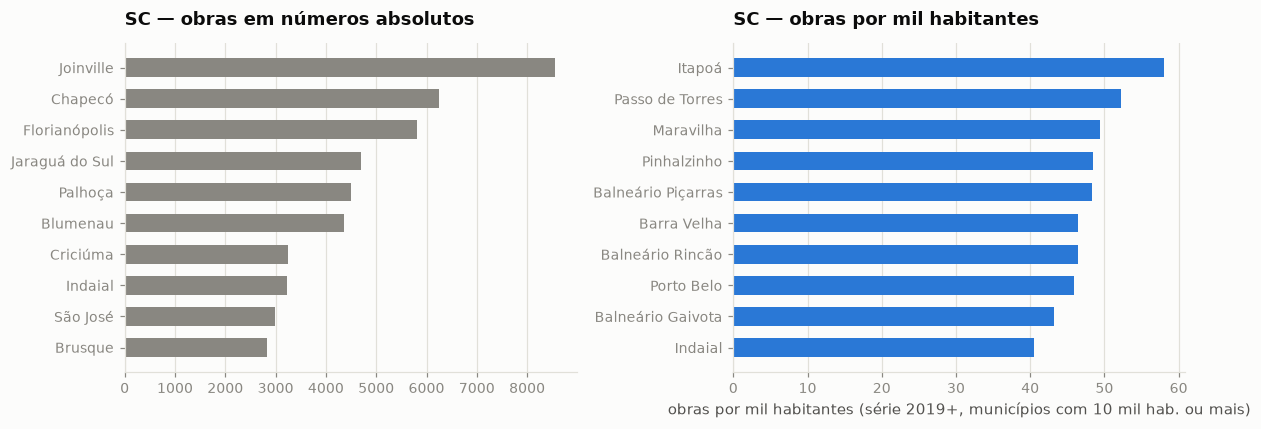

municípios presentes nas duas listas: ['Indaial']


In [16]:
sc = dados.municipios(curada, "SC", comparavel=True)
sc = sc[sc["populacao"] >= 10_000]

topo_absoluto = sc.nlargest(10, "obras")[["nome_ibge", "obras"]]
topo_relativo = sc.nlargest(10, "obras_por_mil_hab")[["nome_ibge", "obras_por_mil_hab"]]

fig, (esq, dir_) = plt.subplots(1, 2, figsize=(11, 4.0))

esq.barh(topo_absoluto["nome_ibge"], topo_absoluto["obras"], height=0.6, color=estilo.CINZA)
esq.invert_yaxis()
esq.set_title("SC — obras em números absolutos")
esq.grid(axis="y", visible=False)

dir_.barh(
    topo_relativo["nome_ibge"], topo_relativo["obras_por_mil_hab"], height=0.6, color=estilo.AZUL
)
dir_.invert_yaxis()
dir_.set_title("SC — obras por mil habitantes")
dir_.set_xlabel("obras por mil habitantes (série 2019+, municípios com 10 mil hab. ou mais)")
dir_.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

print(
    "municípios presentes nas duas listas:",
    sorted(set(topo_absoluto["nome_ibge"]) & set(topo_relativo["nome_ibge"])) or "nenhum",
)

**Das dez posições, nove trocam.** Só Indaial sobrevive à mudança de
denominador. O ranking absoluto mostra os grandes centros — Joinville, Chapecó,
Florianópolis, Blumenau. O ranking por habitante mostra outra Santa Catarina:
Itapoá (58,0 obras por mil habitantes), Passo de Torres, Maravilha, Pinhalzinho,
Balneário Piçarras — **litoral norte e Oeste catarinense**, dois padrões que o
número absoluto escondia por completo.

> **O que mudou no sistema:** a coluna se chama `populacao_2026` e nunca
> `populacao`. Quem escrever o nome genérico recebe erro de coluna inexistente em
> vez de dividir obras de 2026 por um denominador de outra época sem perceber. Há
> teste para isso.

---
## Parte 3 — O que dá para afirmar

Com as nove decisões acima no lugar, os números abaixo são defensáveis. Nenhum
deles seria, sem elas.

,divisao,nome,obras,area_km2,pct_obras,pct_area
0,41,Construção de edifícios,1905075.0,1524.447815,52.9,53.7
1,43,Serviços especializados para construção,1415825.0,525.353053,39.3,18.5
2,42,Obras de infraestrutura,283256.0,789.202524,7.9,27.8


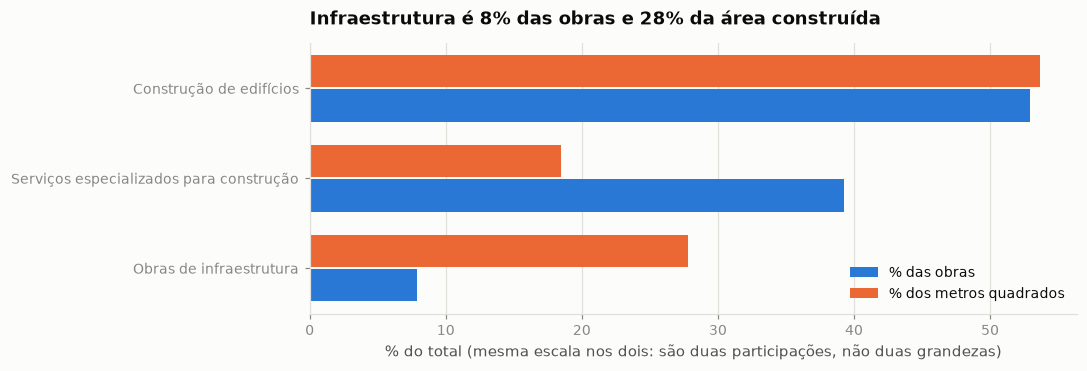

In [17]:
divisoes = dados.divisoes_cnae(curada)
display(divisoes)

fig, ax = plt.subplots(figsize=(9, 3.2))
posicoes = range(len(divisoes))
altura = 0.38
ax.barh(
    [p + altura / 2 for p in posicoes],
    divisoes["pct_obras"],
    height=altura - 0.02,
    color=estilo.AZUL,
    label="% das obras",
)
ax.barh(
    [p - altura / 2 for p in posicoes],
    divisoes["pct_area"],
    height=altura - 0.02,
    color=estilo.LARANJA,
    label="% dos metros quadrados",
)
ax.set_yticks(list(posicoes), divisoes["nome"])
ax.invert_yaxis()
ax.legend(loc="lower right")
ax.set_xlabel("% do total (mesma escala nos dois: são duas participações, não duas grandezas)")
ax.set_title("Infraestrutura é 8% das obras e 28% da área construída")
ax.grid(axis="y", visible=False)
plt.show()

Contar obras e medir área respondem coisas diferentes. **Obras de infraestrutura
são 7,9% dos registros e 27,8% dos metros quadrados**; serviços especializados são
o inverso — 39,3% das obras e 18,5% da área. Um relatório que conta registros diz
que o setor é residencial pulverizado; um que soma área diz que há um terço de
obra pesada. As duas frases são verdadeiras, e citar uma sem a outra é meia
verdade.

Vale registrar o que **não** funcionou: agrupar por *seção* da CNAE daria uma
linha só — 100% da base é seção F (Construção). O recorte útil é a divisão.

,destinacao,obras,area_km2,area_mediana_m2
0,Residencial unifamiliar,2206121,475.900354,106.64
1,Residencial multifamiliar,406027,1045.373246,257.00
2,Comercial salas e lojas,381739,575.877778,351.81
3,não informada,205372,7.154903,480.00
4,Casa popular,187438,10.616842,57.50
5,Galpão industrial,173895,605.500092,530.16
6,Conjunto habitacional popular,33191,64.704478,285.70
7,Edifício de Garagens,10373,53.875700,419.00


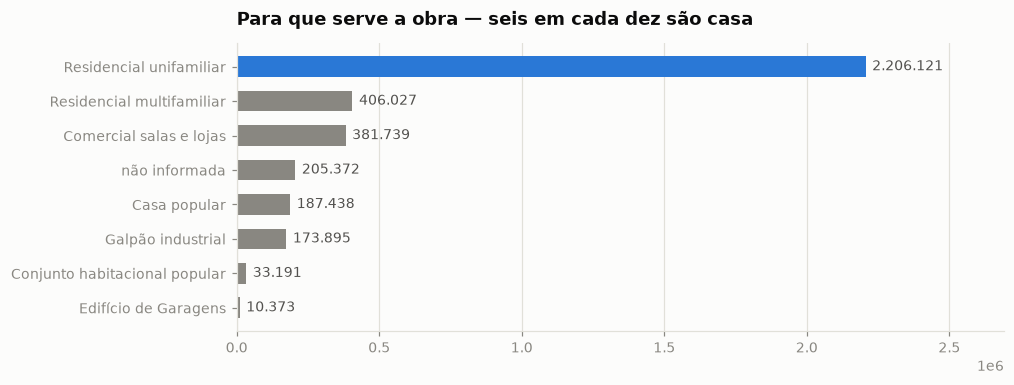

In [18]:
destinos = dados.destinacoes(curada, limite=8)
display(destinos)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(
    destinos["destinacao"],
    destinos["obras"],
    height=0.6,
    color=estilo.enfase(destinos["destinacao"], "Residencial unifamiliar"),
)
ax.invert_yaxis()
estilo.rotular_barras(ax, destinos["obras"])
ax.set_title("Para que serve a obra — seis em cada dez são casa")
ax.set_xlim(0, destinos["obras"].max() * 1.22)
ax.grid(axis="y", visible=False)
plt.show()

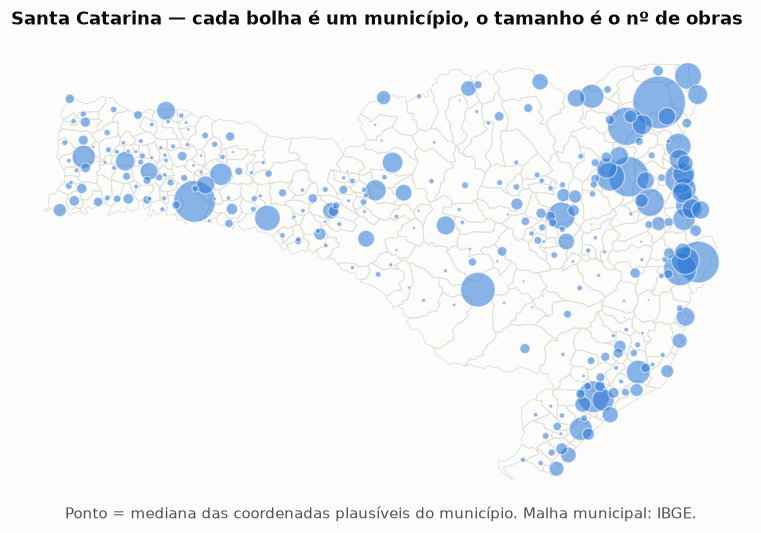

In [19]:
mapa = dados.mapa_municipios(curada, "SC")
contorno = malha.contornos(malha.por_prefixo("42"))

fig, ax = plt.subplots(figsize=(9, 5.4))
for xs, ys in contorno:
    ax.plot(xs, ys, color=estilo.GRADE, linewidth=0.6, zorder=1)
ax.scatter(
    mapa["longitude"],
    mapa["latitude"],
    s=mapa["obras"] / 12,
    color=estilo.AZUL,
    alpha=0.55,
    edgecolor=estilo.SUPERFICIE,
    linewidth=0.8,
    zorder=2,
)
ax.set_title("Santa Catarina — cada bolha é um município, o tamanho é o nº de obras")
ax.set_xlabel("Ponto = mediana das coordenadas plausíveis do município. Malha municipal: IBGE.")
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.grid(visible=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

In [20]:
dados.regioes(curada, "SC")

,regiao,municipios,obras,populacao,obras_por_mil_hab,area_km2
0,Blumenau,60,69005.0,2332954.0,29.6,75.804805
1,Chapecó,109,50770.0,1277538.0,39.7,25.991419
2,Joinville,25,43932.0,1562633.0,28.1,27.393342
3,Criciúma,44,30373.0,1070106.0,28.4,16.550589
4,Florianópolis,17,25920.0,1452624.0,17.8,27.169317
5,Lages,24,11517.0,378754.0,30.4,5.829221
6,Caçador,16,7497.0,238150.0,31.5,3.794881


Por região intermediária, **Chapecó tem 39,7 obras por mil habitantes contra 17,8
de Florianópolis** — mais que o dobro, com um terço da população da região da
capital. É o mesmo padrão dos municípios: o Oeste catarinense constrói muito para
o seu tamanho.

---
## O que **não** dá para afirmar

Uma análise honesta declara os limites antes que alguém os descubra.

1. **O CNO não mede o setor da construção; mede o cadastro dele.** Obra que não
   precisa de matrícula não está aqui. A base é excelente para "onde há obra
   cadastrada" e não serve para PIB setorial.

2. **O ano é o de início declarado, não o de execução.** Uma obra cadastrada em
   2022 com início em 1997 entra em 1997. A série mede quando as obras
   *começaram*, entre as que existem no cadastro hoje.

3. **Antes de 2019 a série não é comparável**, pelo degrau de recadastramento, e
   **o último ano nunca está fechado** — o snapshot é de setembro, então 2026 tem
   três meses e meio faltando. Ler queda onde há corte de calendário é o erro mais
   fácil de cometer aqui. O corte de 2019 está implementado, mas a data exata da
   norma ainda precisa ser conferida antes de virar afirmação pública.

4. **58,8% das obras não têm ponto no mapa**, e a ausência não é aleatória:
   depende de o cadastro ter sido preenchido com Plus Code, o que varia por época
   e por município. Todo mapa aqui é de um subconjunto — nunca da base.

5. **Área existe para 94% das obras e é autodeclarada.** 323 registros
   impossíveis foram marcados, mas não há como validar os 3,4 milhões plausíveis
   contra nada externo.

6. **População é de 2026 e as obras são de todos os anos.** A taxa por mil
   habitantes usa denominador de hoje para numerador acumulado. Serve para
   comparar municípios entre si no mesmo instante; não serve como série
   histórica.

7. **Duas obras dizem estar no Brasil e num município chamado `EXTERIOR`.** A
   fonte se contradiz, e o pipeline preserva a contradição em vez de escolher um
   lado.

---
### Onde cada decisão virou código

| Achado | Onde mora no pipeline |
|---|---|
| Encoding cp1252 | `config.py` · `transform/transcodificacao.py` |
| Nulo que é PF | `transform/schema.py` → `responsavel_tipo` |
| Reconciliação com a fonte | `extract/manifest.py` · `validate/` |
| Unidade e área implausível | `curate/sql.py` → `area_m2`, `area_suspeita` |
| Uma linha por obra | `curate/sql.py` → `n_areas`, `n_cnaes` |
| Plus Code e plausibilidade | `curate/geocodificacao.py` → `geo_plausivel` |
| Corte da série | `curate/dominios.py` → `PRIMEIRO_ANO_COMPARAVEL` |
| IBGE fora do pipeline | `analise/referencias.py` · DAG `referencias_ibge` |

A entrega da análise é o dashboard: `make dashboard`.